To beginn, here are some usefull links: \
The original [xarray tutorial](https://tutorial.xarray.dev/overview/xarray-in-45-min.html), and link for useful basics of [Jupyter Notebooks in Visual Code](https://code.visualstudio.com/docs/datascience/jupyter-notebooks)

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

xr.set_options(keep_attrs=True, display_expand_data=False)
np.set_printoptions(threshold=10, edgeitems=2)

%xmode minimal
%matplotlib inline
%config InlineBackend.figure_format='retina'

Exception reporting mode: Minimal


In [5]:
#dataset
ds = xr.tutorial.load_dataset("air_temperature")
ds

/home/pjunghans/miniconda3/envs/mesmer-tests/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2920, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 31MB 241.2 242.5 243.5 ... 296.2 295.7
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [6]:
#the dataarry and it's labels 
ds.variables
ds.all
da = ds.air
da.name
da.dims
da.coords
lon= da.lon #or da.coords["lon"]
da.attrs ["my_own_attribut"] = "crazzy"
da.attrs


{'long_name': '4xDaily Air temperature at sigma level 995',
 'units': 'degK',
 'precision': np.int16(2),
 'GRIB_id': np.int16(11),
 'GRIB_name': 'TMP',
 'var_desc': 'Air temperature',
 'dataset': 'NMC Reanalysis',
 'level_desc': 'Surface',
 'statistic': 'Individual Obs',
 'parent_stat': 'Other',
 'actual_range': array([185.16, 322.1 ], dtype=float32),
 'my_own_attribut': 'crazzy'}

In [7]:
#The data below
da.data
type(da.data)
da.lon.data
type(da.lon.data)

ds.air.time[0].values



np.datetime64('2013-01-01T00:00:00.000000000')

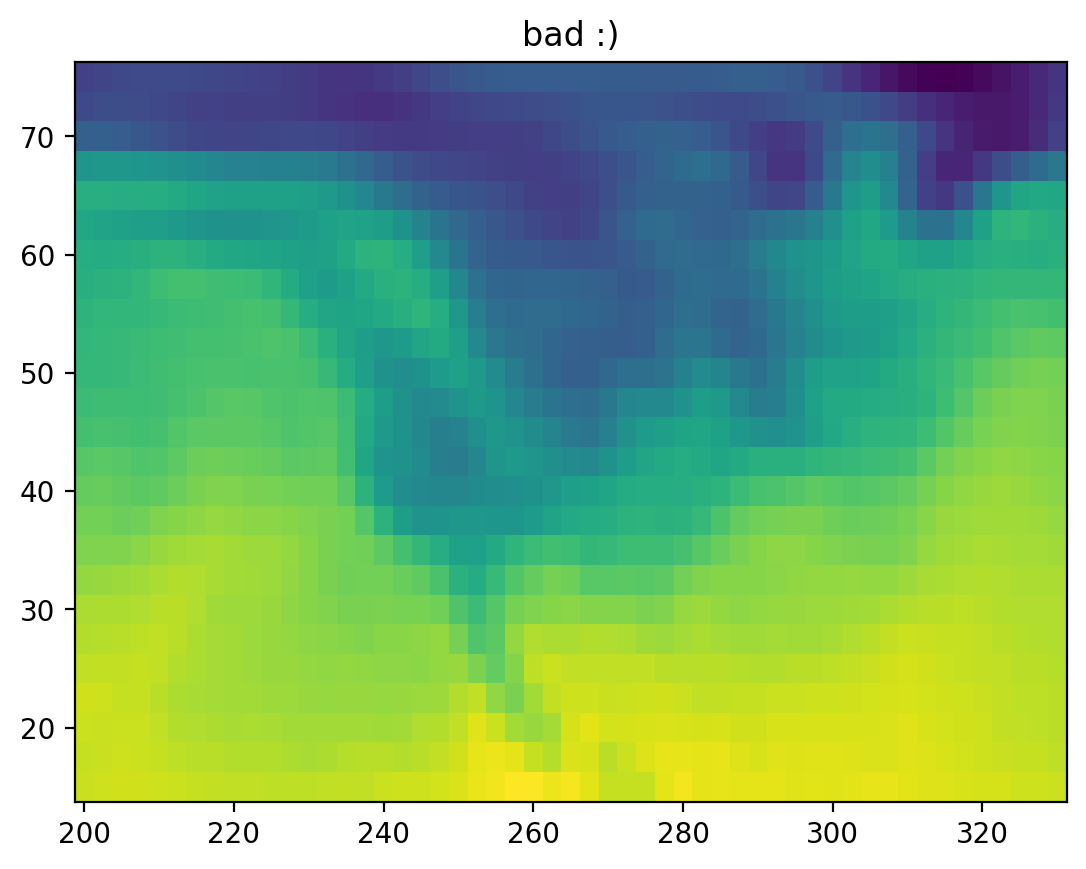

In [8]:
#bad Plot
# plot the first timestep
lat = ds.air.lat.data  # numpy array
lon = ds.air.lon.data  # numpy array
temp = ds.air.data  # numpy array

plt.figure()
plt.title("bad :)")
plt.pcolormesh(lon, lat, temp[0, :, :]);

#temp.mean(axis=1)  ## what did I just do? I can't tell by looking at this line.

label based indexing (select a used index): .sel \
position based indexing (select a used index): .isel  


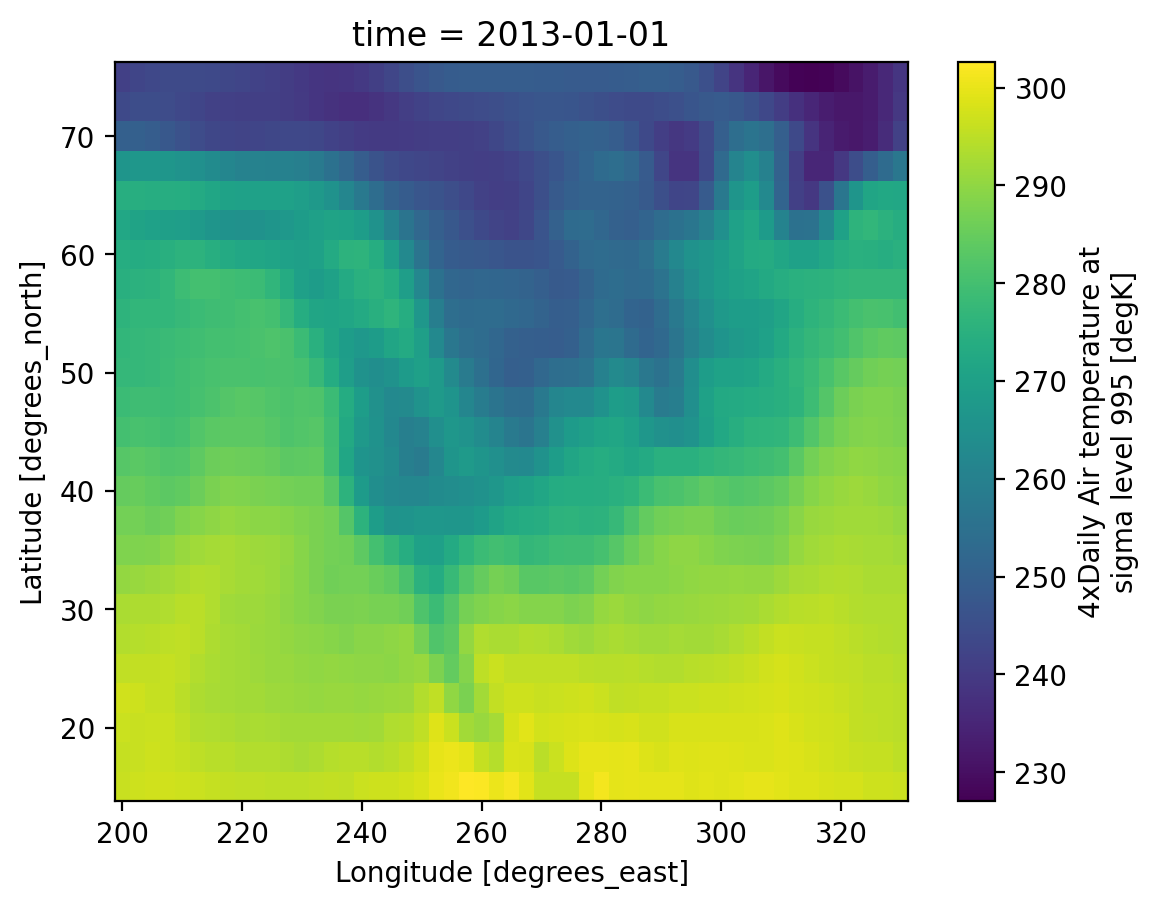

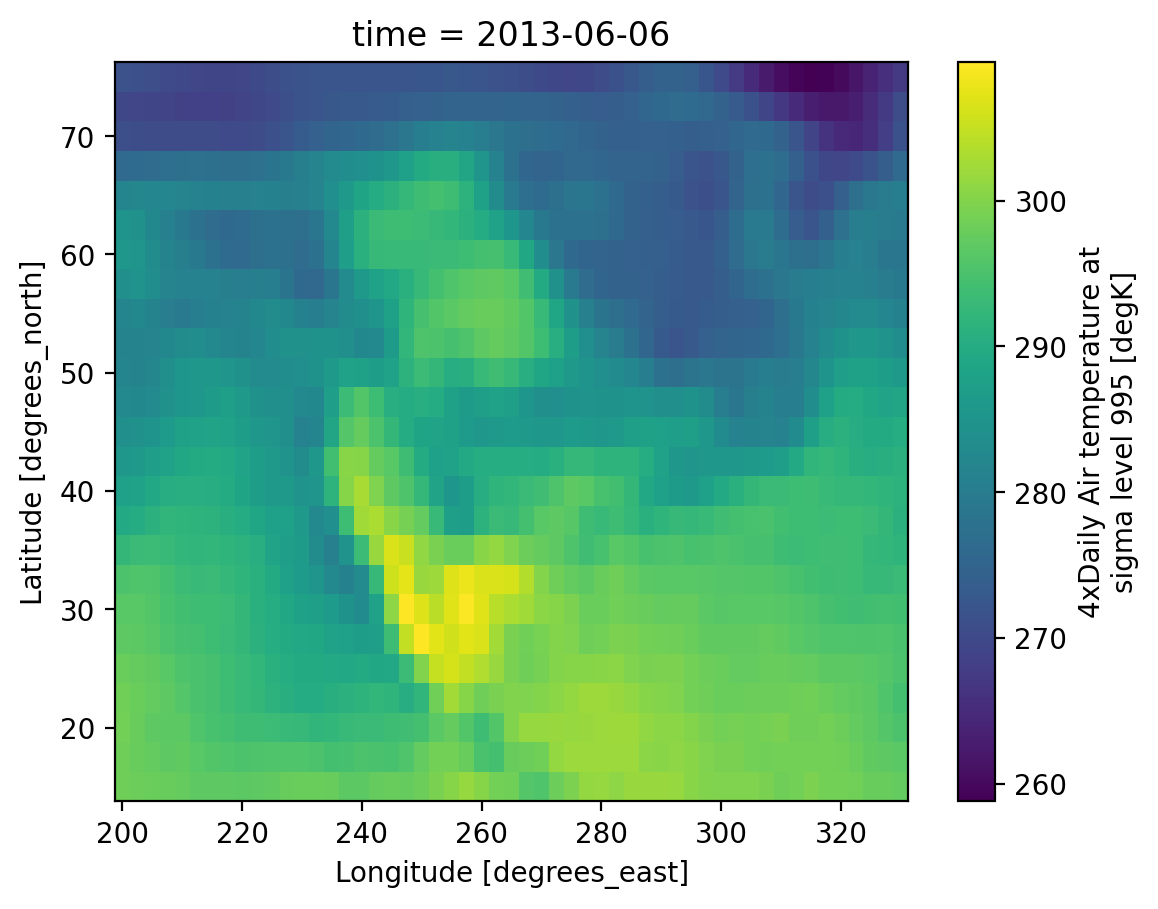

In [9]:
#better Plot, code nur so semi lesbar:)
ds.air.isel(time=0).plot(x="lon");
plt.show()
ds.air.sel(time='2013-06-06T00:00:00.000000000').plot(x="lon");
plt.show()

In [10]:
ds.sel(time="2013")
ds.sel(time="2013-05")
ds.sel(time=slice("2013-05","2013-07"))
ds.sel(lon=240.2, method = "nearest")
ds.sel(lon=[240.125, 234], lat=[40.3, 50.3], method="nearest")

<xarray.Dataset> Size: 117kB
Dimensions:  (time: 2920, lat: 2, lon: 2)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 8B 40.0 50.0
  * lon      (lon) float32 8B 240.0 235.0
Data variables:
    air      (time, lat, lon) float64 93kB 268.1 283.0 265.5 ... 256.8 268.6
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

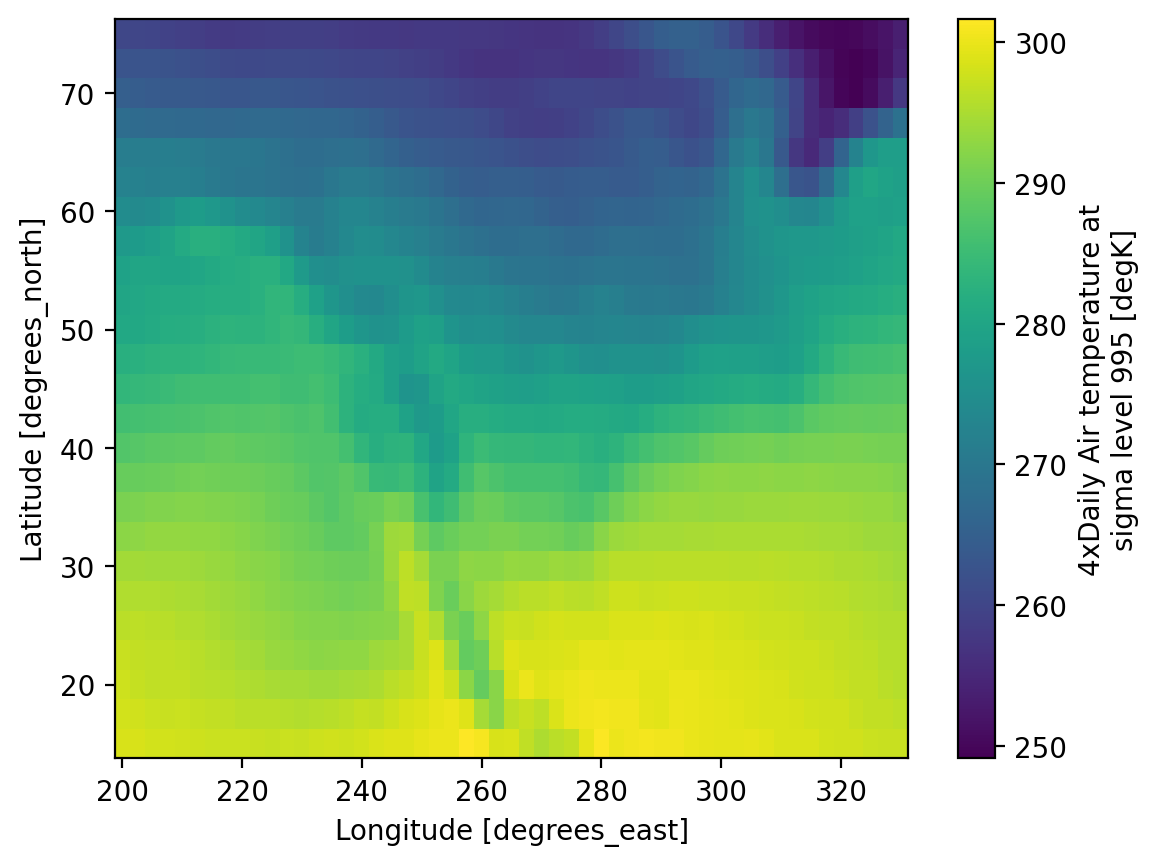

In [11]:
#better plot and readable
ds.air.mean(dim="time").plot(x="lon");

In [12]:
#Ein Blick aufs ganze:)
ds

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2920, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 31MB 241.2 242.5 243.5 ... 296.2 295.7
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [13]:
da.data[0,2,3] #möglich
da.isel(time=0,lat=2,lon=3) #besser zu lesen
da.isel(time=0,lon=3,lat=2)
da.isel(lon = slice(4)) #nimmt die ersten 4 Werte

<xarray.DataArray 'air' (time: 2920, lat: 25, lon: 4)> Size: 2MB
241.2 242.5 243.5 244.0 243.8 244.5 ... 297.2 297.5 297.7 298.1 298.1 298.5
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 16B 200.0 202.5 205.0 207.5
Attributes:
    long_name:        4xDaily Air temperature at sigma level 995
    units:            degK
    precision:        2
    GRIB_id:          11
    GRIB_name:        TMP
    var_desc:         Air temperature
    dataset:          NMC Reanalysis
    level_desc:       Surface
    statistic:        Individual Obs
    parent_stat:      Other
    actual_range:     [185.16 322.1 ]
    my_own_attribut:  crazzy

## Concepts for computation
Als Grundlage ist zu beachten: $(\delta Lat = R\delta \phi)$ und $(\delta Lon = R \delta \lambda \cos(\phi))$
Daraus erhalten wir die Fläche eines Einheitquadrates: $\delta A = R^2 \delta \phi \delta \lambda \cos(\phi)$

In [14]:
# Earth's average radius in meters
R = 6.371e6

# Coordinate spacing for this dataset is 2.5 x 2.5 degrees
dϕ = np.deg2rad(2.5)
dλ = np.deg2rad(2.5)

dlat = R * dϕ * xr.ones_like(ds.air.lon) #xr.ones_like gibt  ein Objekt zurück wie das in den Klammern aber gefüllt mit 1ern.
dlon = R * dλ * np.cos(np.deg2rad(ds.air.lat)) #np.cos... gibt wieder metamässig gleichen XArray
dlon.name = "dlon"
dlat.name = "dlat"

# returns an xarray DataArray!
np.cos(np.deg2rad(ds.lat))
ds.lat

dlat
dlon

<xarray.DataArray 'dlon' (lat: 25)> Size: 200B
7.195e+04 8.359e+04 9.508e+04 1.064e+05 ... 2.612e+05 2.651e+05 2.685e+05
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
Attributes:
    standard_name:  latitude
    long_name:      Latitude
    units:          degrees_north
    axis:           Y

## Broadcasting:expanding data
Our longitude and latitude length DataArrays are both 1D with different dimension names. If we multiply these DataArrays together the dimensionality is expanded to 2D by broadcasting:
Da Xarray die Dimensions nahmen kennt, handelt er bei * entsprechend siehe [user guide](https://docs.xarray.dev/en/stable/user-guide/computation.html#broadcasting-by-dimension-name) für mehr Detail.

In [15]:
cell_area = dlon * dlat
cell_area

<xarray.DataArray (lat: 25, lon: 53)> Size: 11kB
2e+10 2e+10 2e+10 2e+10 2e+10 ... 7.464e+10 7.464e+10 7.464e+10 7.464e+10
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0

In [16]:
# Aus user guide  erstellen eines Xarrays:
b = xr.DataArray([-1, -2, -3], [("y", [10, 20, 30])])
b

<xarray.DataArray (y: 3)> Size: 24B
-1 -2 -3
Coordinates:
  * y        (y) int64 24B 10 20 30

In [17]:
da/cell_area
da.isel(time = 1)/cell_area

<xarray.DataArray (lat: 25, lon: 53)> Size: 11kB
1.21e-08 1.213e-08 1.215e-08 1.217e-08 ... 3.971e-09 3.971e-09 3.974e-09
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
    time     datetime64[ns] 8B 2013-01-01T06:00:00
Attributes:
    long_name:        4xDaily Air temperature at sigma level 995
    units:            degK
    precision:        2
    GRIB_id:          11
    GRIB_name:        TMP
    var_desc:         Air temperature
    dataset:          NMC Reanalysis
    level_desc:       Surface
    statistic:        Individual Obs
    parent_stat:      Other
    actual_range:     [185.16 322.1 ]
    my_own_attribut:  crazzy

In [18]:
# We produce a non-alligned copy:
# make a copy of cell_area
# then add 1e-5 degrees to latitude
cell_area_bad = cell_area.copy(deep=True)
cell_area_bad["lat"] = cell_area.lat + 1e-5  # latitudes are off by 1e-5 degrees!
cell_area_bad
cell_area_bad * da.isel(time=1)
#die nicht passende Dimension wird neutral als zwei vektoren betrachtet ohne Koordinaten

#xr.align(cell_area_bad,da, join = "exact") 
#gibt Fehlermeldung, das 'lat' nicht allignebar ist



<xarray.DataArray (lat: 0, lon: 53)> Size: 0B

Coordinates:
  * lat      (lat) float32 0B 
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
    time     datetime64[ns] 8B 2013-01-01T06:00:00
Attributes:
    long_name:        4xDaily Air temperature at sigma level 995
    units:            degK
    precision:        2
    GRIB_id:          11
    GRIB_name:        TMP
    var_desc:         Air temperature
    dataset:          NMC Reanalysis
    level_desc:       Surface
    statistic:        Individual Obs
    parent_stat:      Other
    actual_range:     [185.16 322.1 ]
    my_own_attribut:  crazzy

For more Details about broadcasting: [Xarray documentation](https://docs.xarray.dev/en/stable/user-guide/computation.html#automatic-alignment), [Tutorial notebook](https://tutorial.xarray.dev/fundamentals/02.3_aligning_data_objects.html)

## High level Coputation

<span style="color:red"> links noch nicht angesehen. rolling und coarsen fast gar nicht betrachtet </span>

Xarray has some very useful high level objects that let you do common computations:

1. groupby : [Bin data in to groups and reduce](https://docs.xarray.dev/en/stable/groupby.html)

2. resample : [Groupby specialized for time axes. Either downsample or upsample your data.](https://docs.xarray.dev/en/stable/user-guide/time-series.html#resampling-and-grouped-operations)

3. rolling : [Operate on rolling windows of your data e.g. running mean](https://docs.xarray.dev/en/stable/user-guide/computation.html#rolling-window-operations)

4. coarsen : [Downsample your data](https://docs.xarray.dev/en/stable/user-guide/computation.html#coarsen-large-arrays)

5. weighted : [Weight your data before reducing](https://docs.xarray.dev/en/stable/user-guide/computation.html#weighted-array-reductions)

Below we quickly demonstrate these patterns. See the user guide links above and [the tutorial](https://tutorial.xarray.dev/intermediate/01-high-level-computation-patterns.html) for more.

### groupby

In [19]:
ds.attrs
ds

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2920, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 31MB 241.2 242.5 243.5 ... 296.2 295.7
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [20]:
# seasonal groups
ds.groupby("time.season")

<DatasetGroupBy, grouped over 1 grouper(s), 4 groups in total:
    'season': UniqueGrouper('season'), 4/4 groups with labels 'DJF', 'JJA', 'MAM', 'SON'>

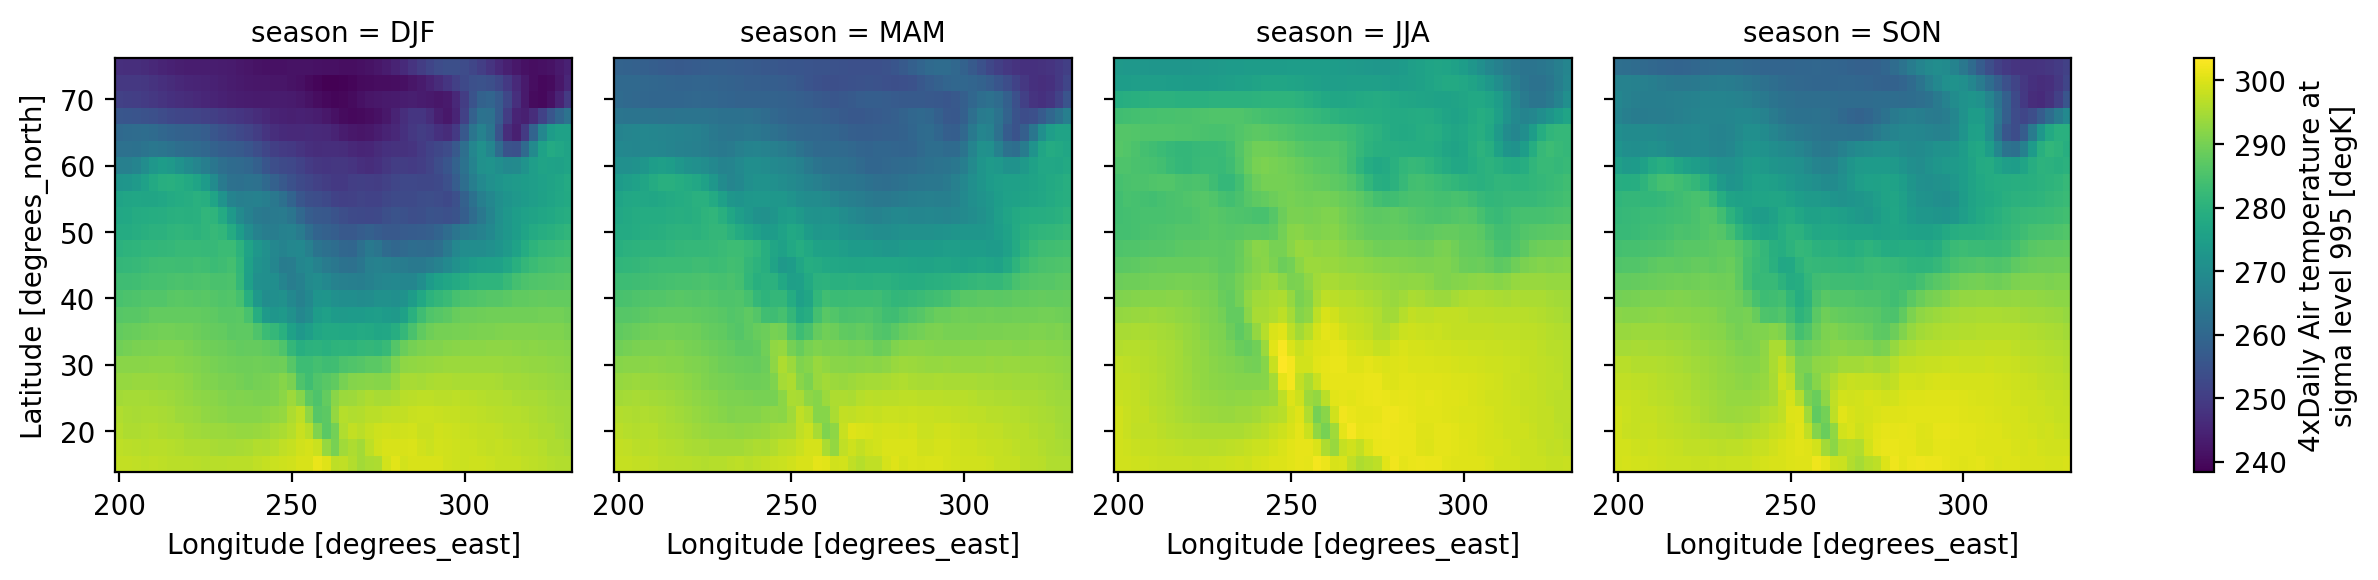

In [36]:
# make a seasonal mean
seasonal_mean = ds.groupby("time.season").mean()
seasonal_mean.air.data
seasonal_mean

# Um Alphabetische Ordnung zu umgehen:
seasonal_mean = seasonal_mean.sel(season=["DJF", "MAM", "JJA", "SON"])
seasonal_mean

# und ein Plot
seasonal_mean.air.plot(col="season");

### resample & weighted



In [22]:
# resample to monthly frequency
ds.resample(time="ME").mean() 

<xarray.Dataset> Size: 255kB
Dimensions:  (time: 24, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 192B 2013-01-31 2013-02-28 ... 2014-12-31
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 254kB 244.5 244.7 244.7 ... 297.7 297.7
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

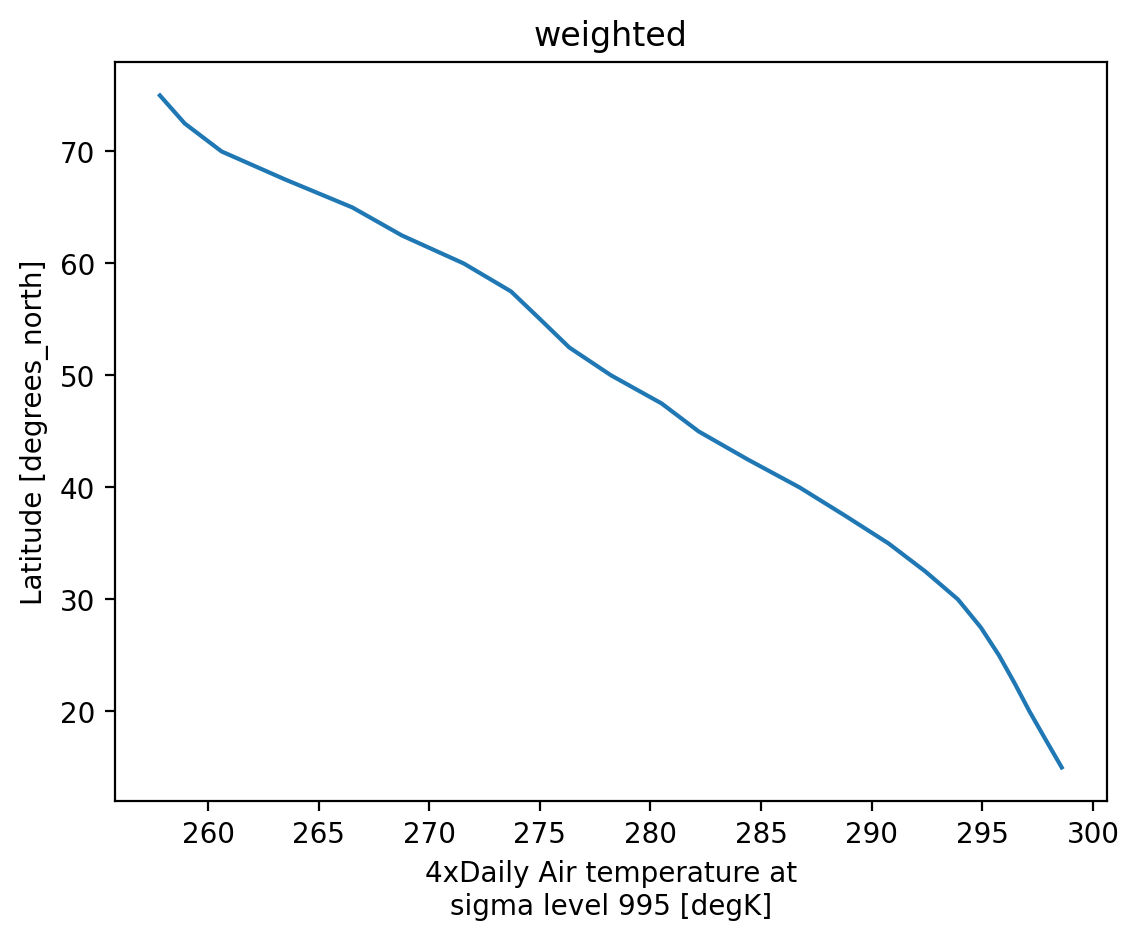

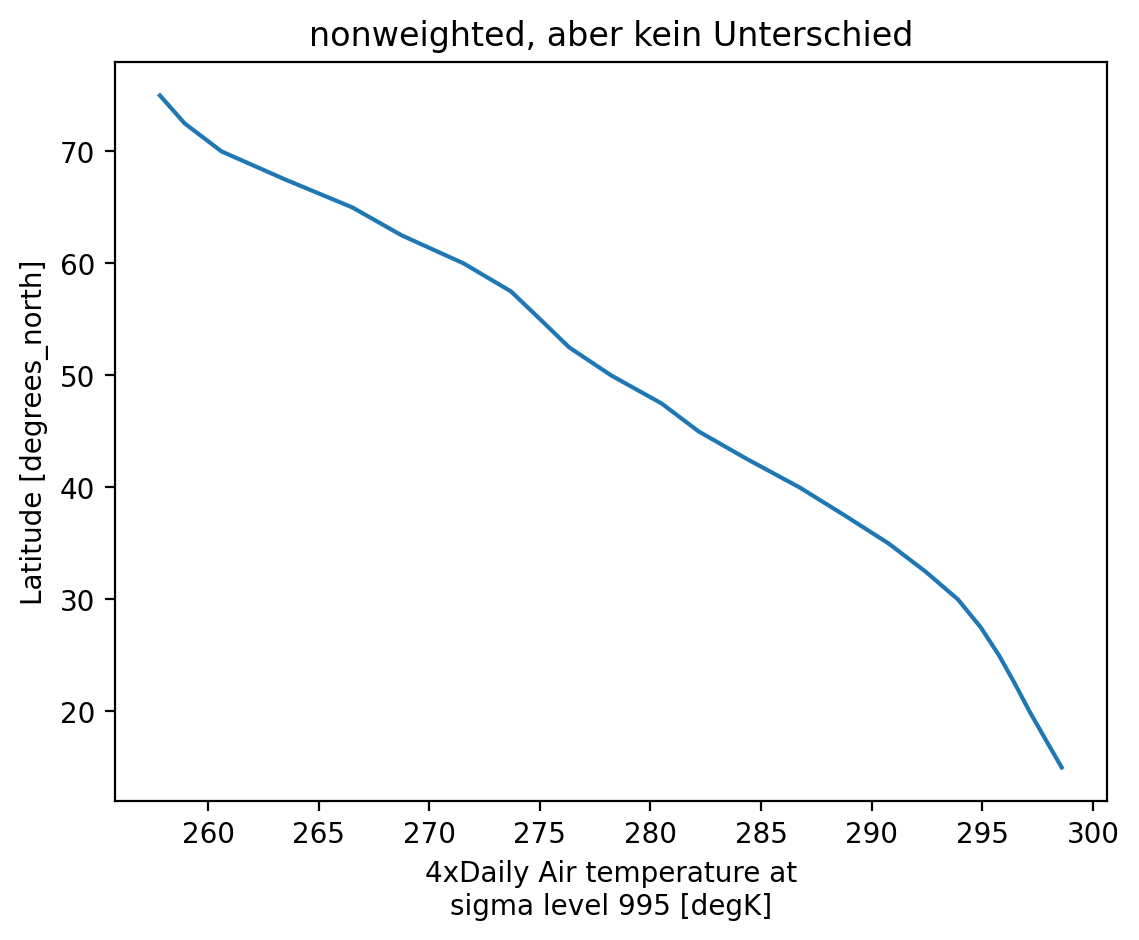

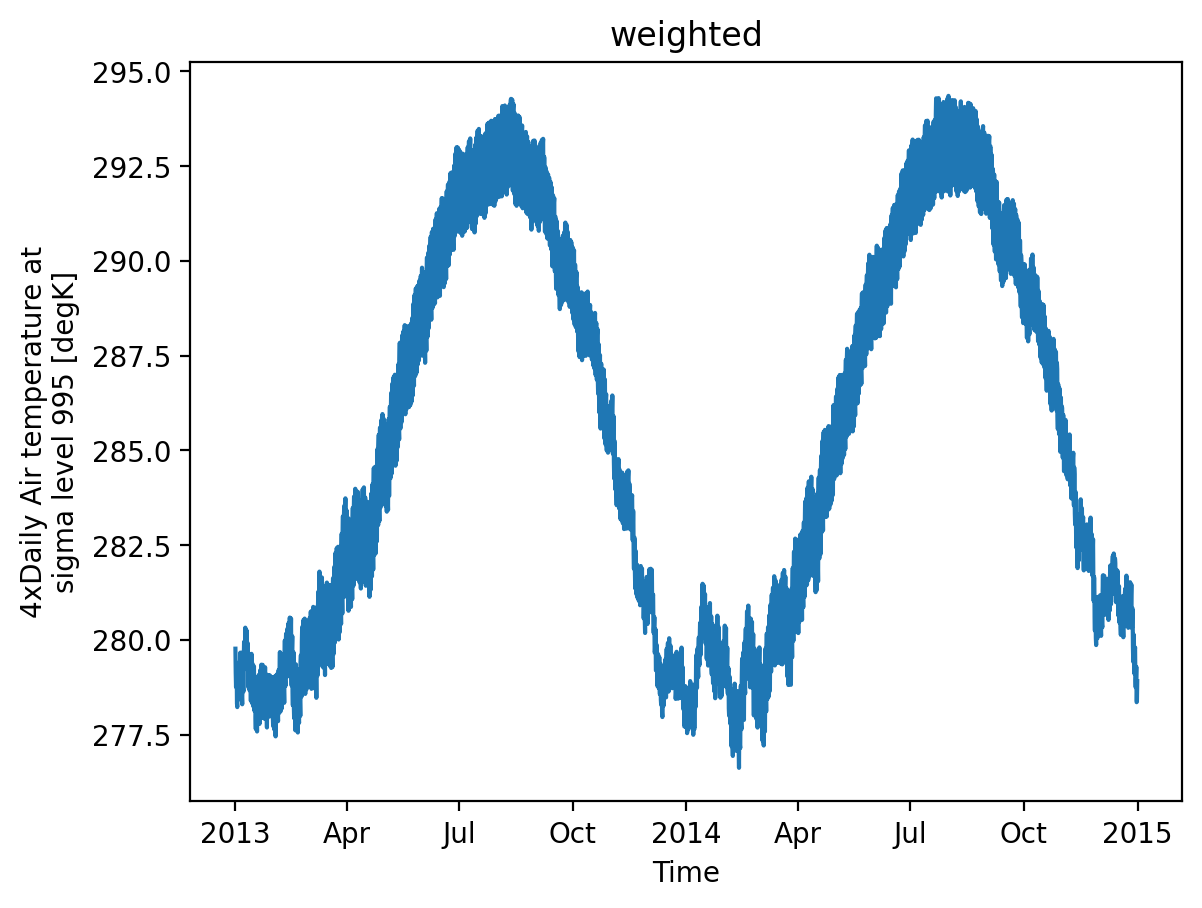

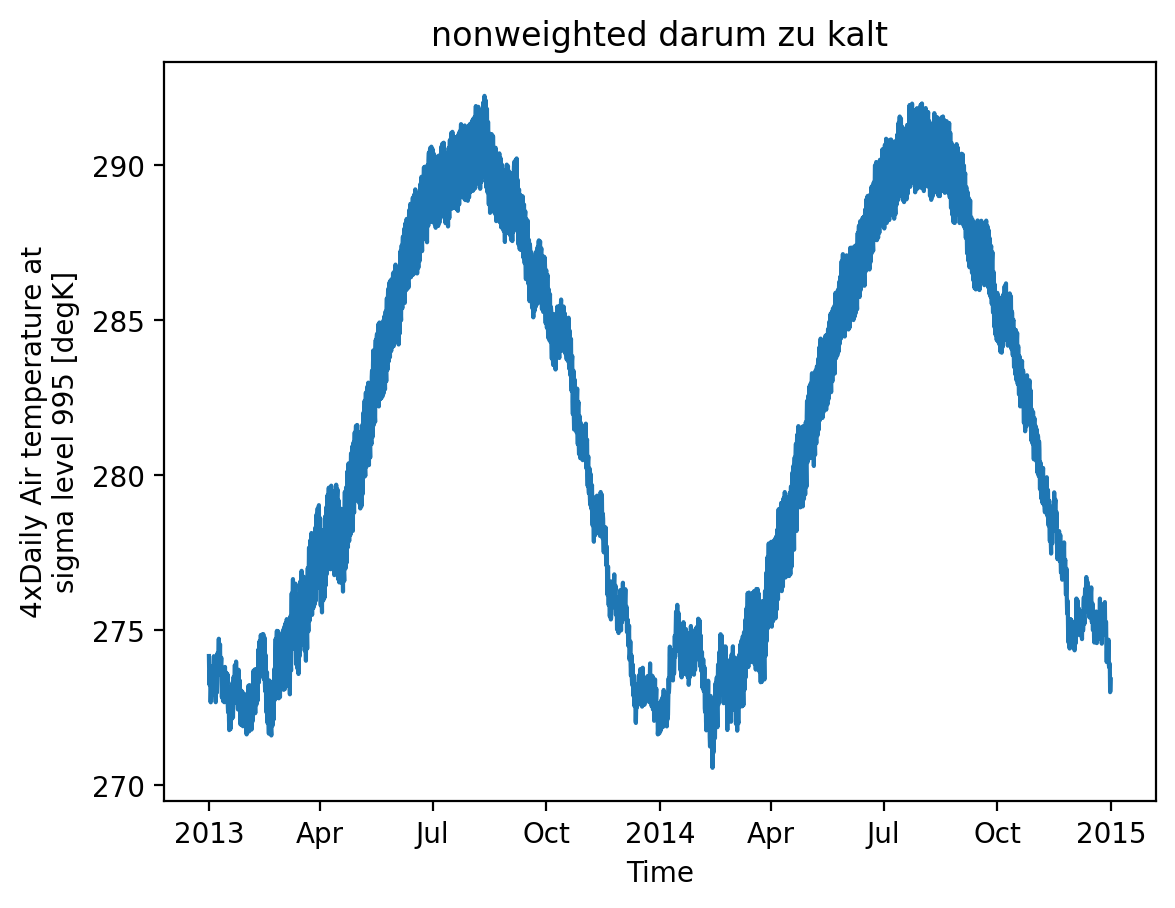

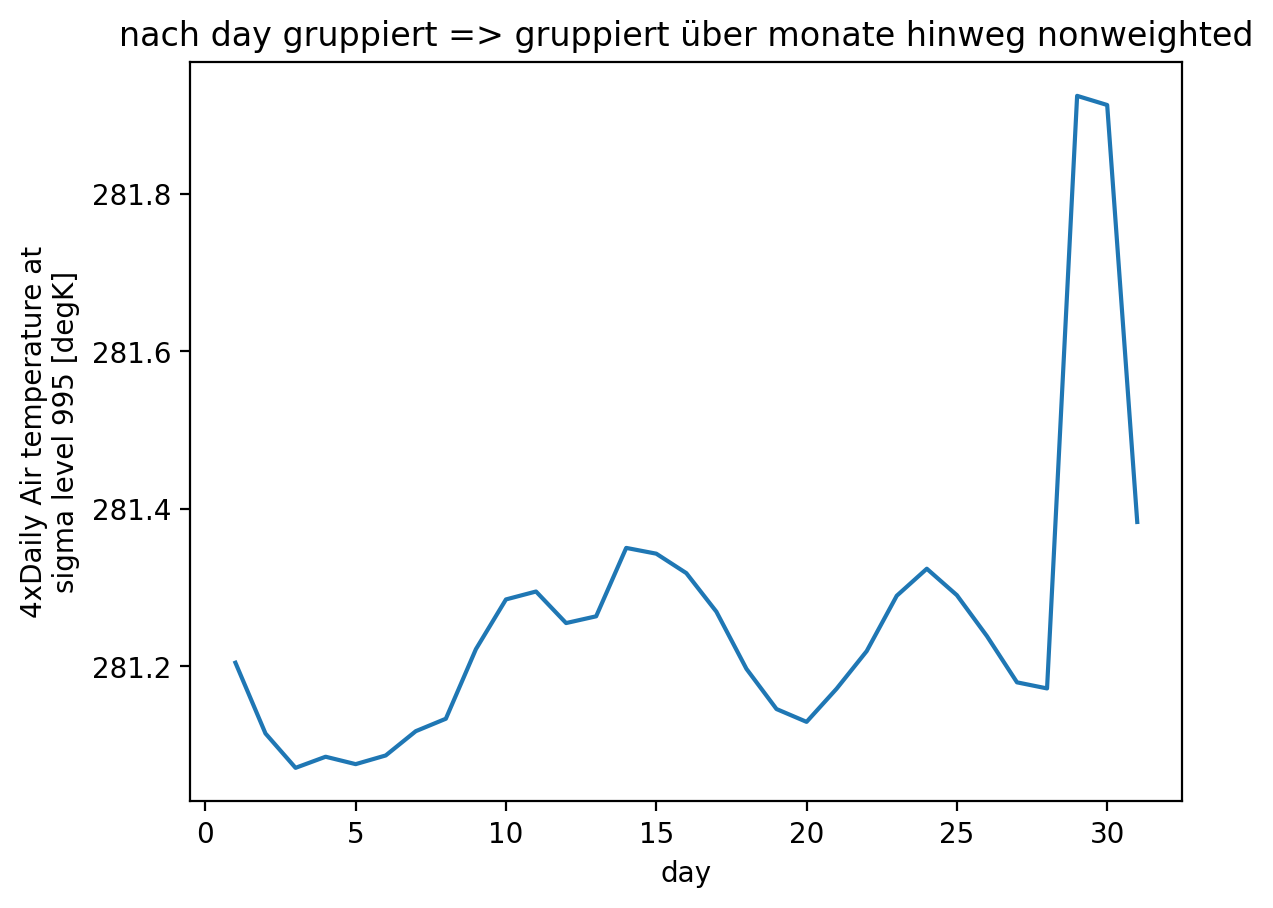

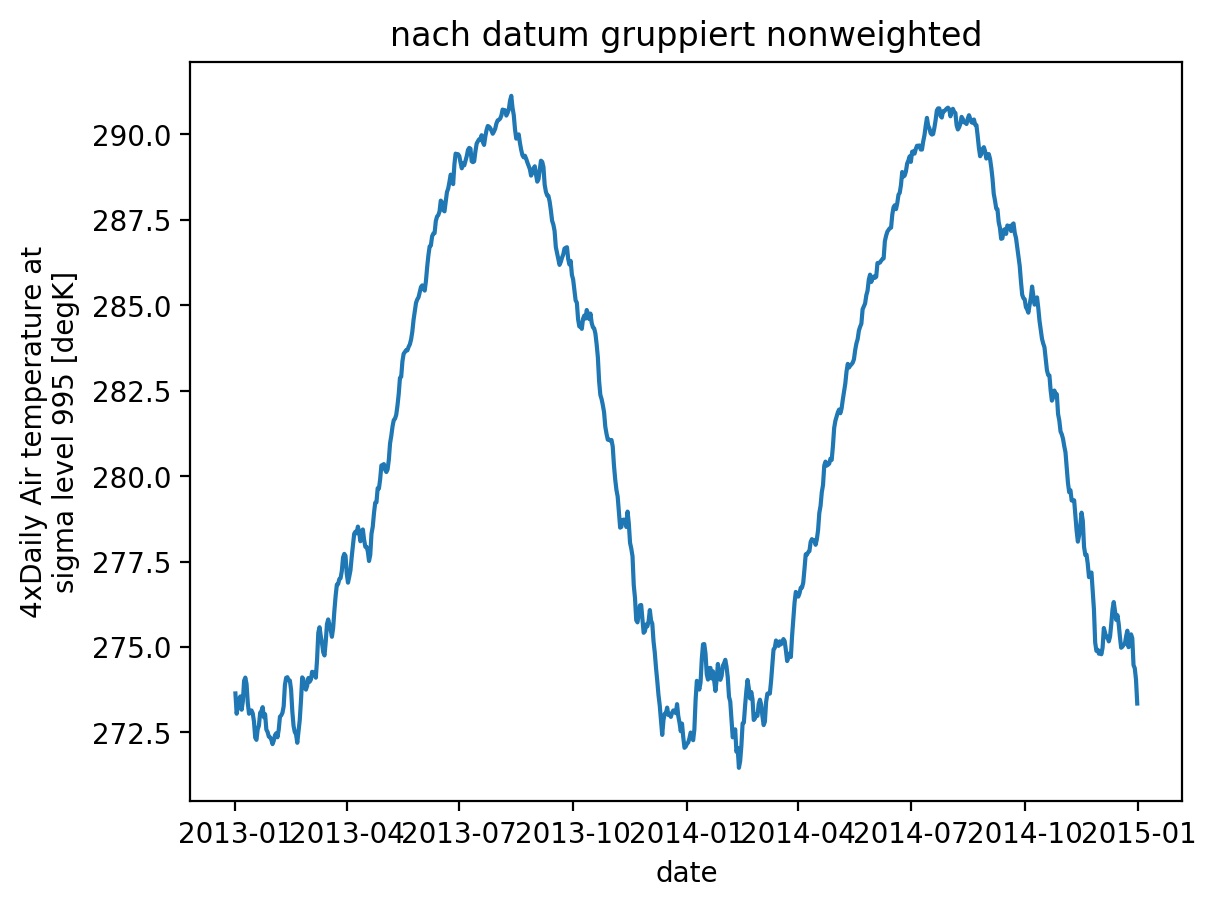

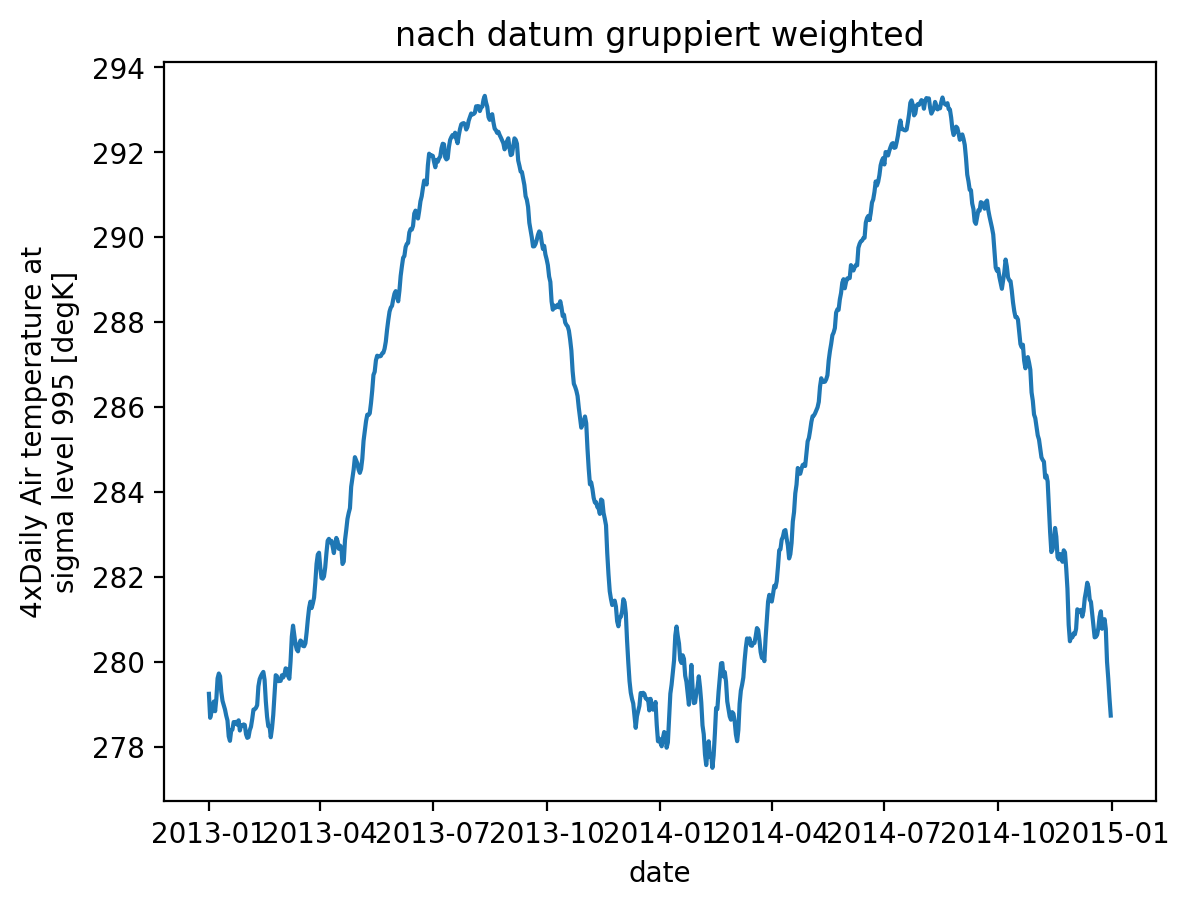

DatasetWeighted with weights along dimensions: lat, lon

In [ ]:
# weight by cell_area and take mean over (time, lon)
ds.weighted(cell_area).mean(["lon", "time"]).air.plot(y="lat"); 
plt.title("weighted")
plt.show()

ds.mean(["lon", "time"]).air.plot(y="lat");
plt.title("nonweighted, aber kein Unterschied")
plt.show() #diese Resultat sieht gleich aus, da gleiche lat => gleiche cell_area

ds.weighted(cell_area).mean(["lon", "lat"]).air.plot(x="time");
plt.title("weighted")
plt.show()

ds.mean(["lon", "lat"]).air.plot(x="time");
plt.title("nonweighted darum zu kalt")
plt.show() #Hier sieht man den Fehler (kälter), da Temperaturen der "Polregion" zu stark gewertet werden

#group by date, (less wiggle:)
ds.groupby("time.day").mean().mean(["lon", "lat"]).air.plot(x="day");
plt.title("nach day gruppiert => gruppiert über monate hinweg nonweighted")
plt.show() #Alle gleichen tage der unterschiedlichen Monate in einen Topf geworfen:)

ds.groupby("time.date").mean().mean(["lon", "lat"]).air.plot(x="date");
plt.title("nach datum gruppiert nonweighted")
plt.show() # jeweils Mittelwert über den ganzen Tag

# #group by date, (less wiggle:), also weighted
ds.groupby("time.date").mean().weighted(cell_area).mean(["lon", "lat"]).air.plot(x="date");
plt.title("nach datum gruppiert weighted")
plt.show() # jeweils Mittelwert über den ganzen Tag



## Fancy Plot possibilities

Auch um mit vielen Dimensionen um gehen zu können, noch einiges mehr möglich schätze ich :)

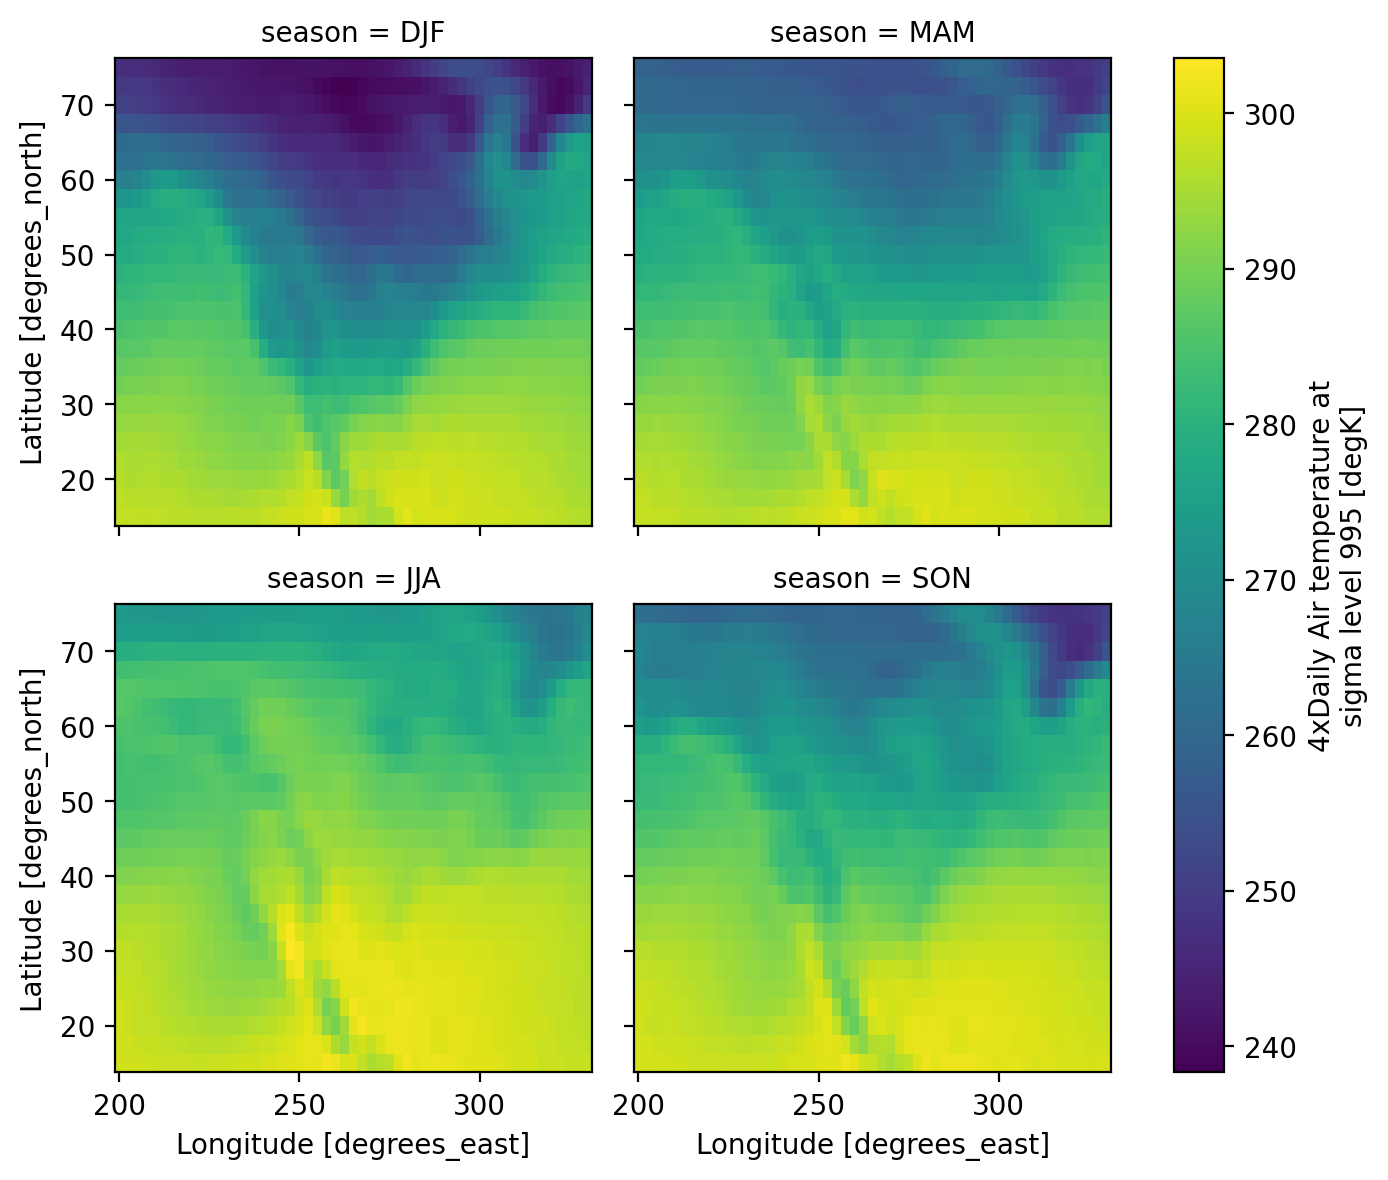

In [24]:
# facet the seasonal_mean
seasonal_mean.air.plot(col="season", col_wrap=2); 
#col_wrap sagt einfach wie viele Plots nebeneinander

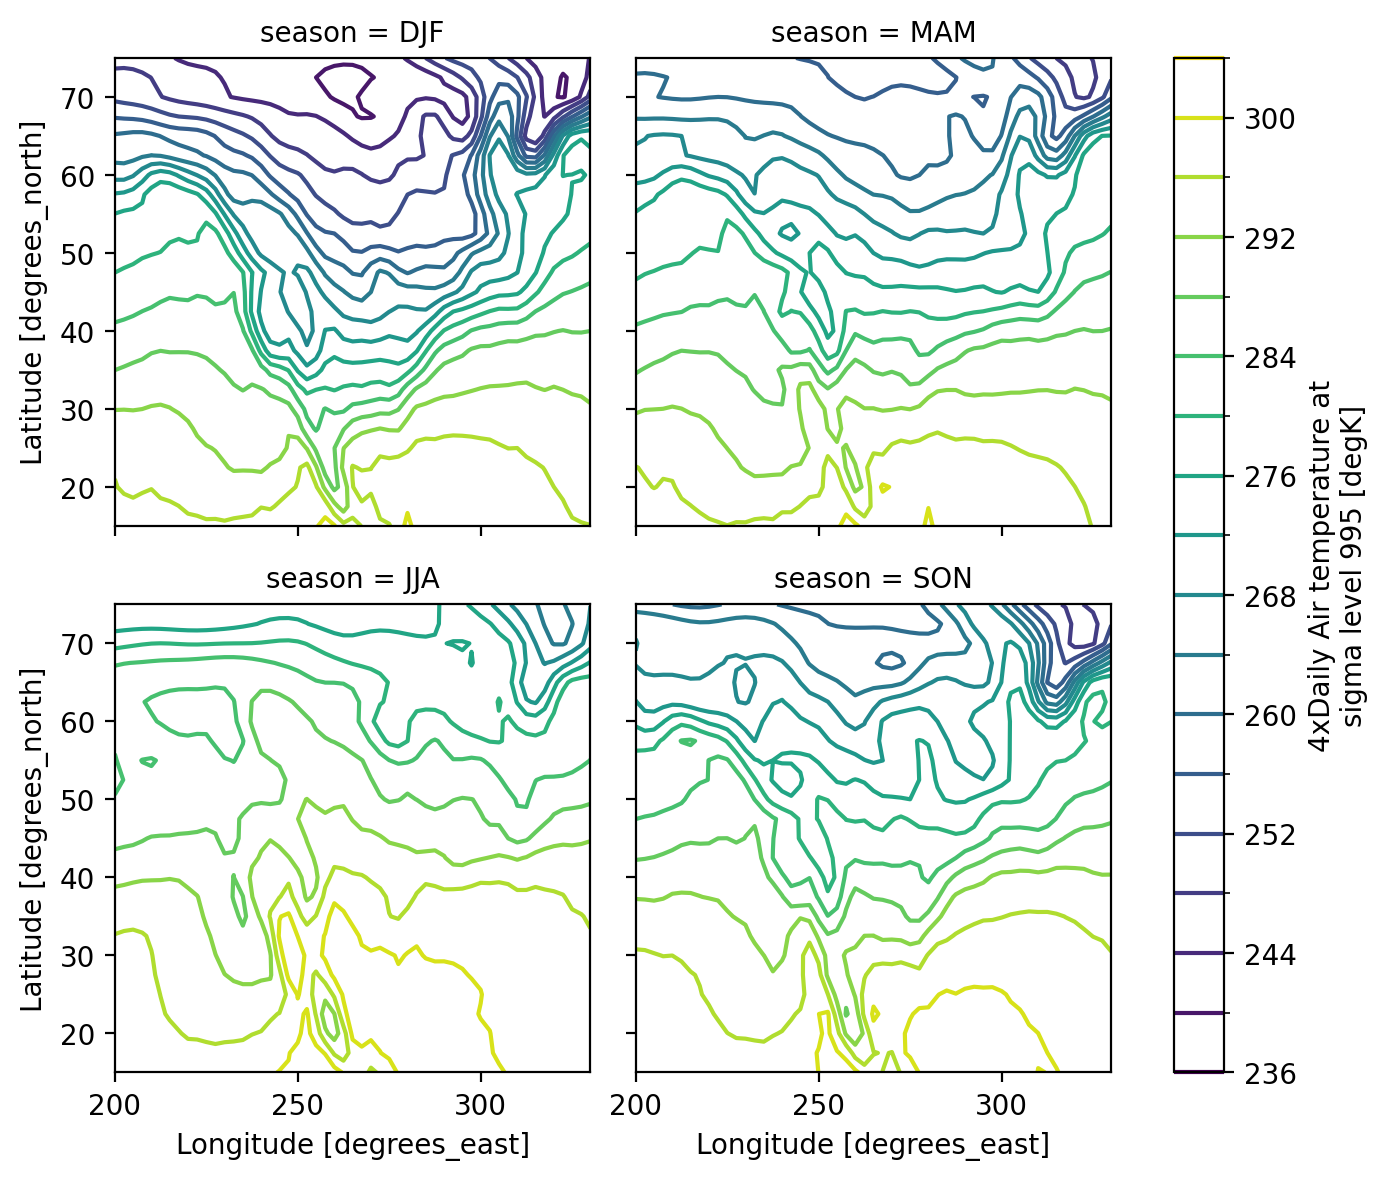

In [25]:
# contours
seasonal_mean.air.plot.contour(col="season", levels=20, add_colorbar=True, col_wrap=2);
# levels gibt an wieviele temperaturgruppen es geben soll

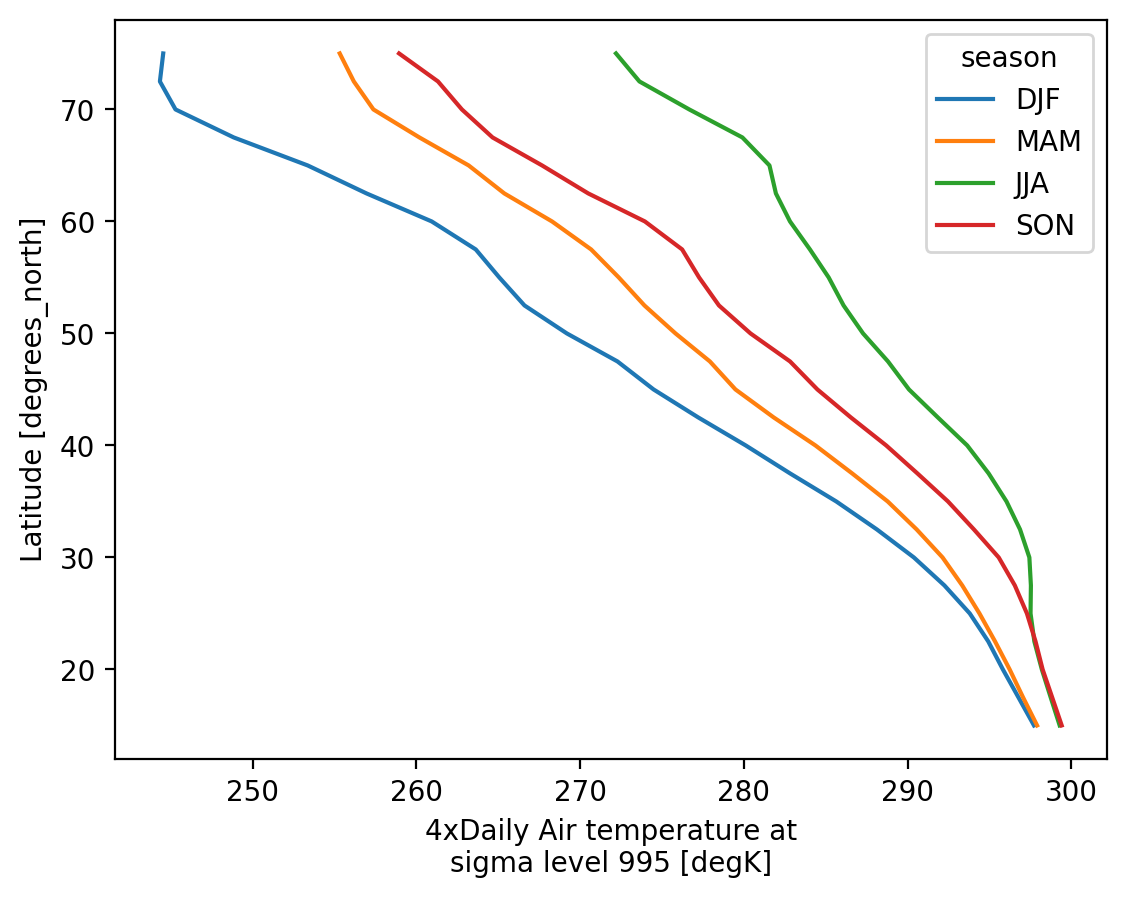

In [26]:
# line plots
seasonal_mean.air.mean("lon").plot.line(hue="season", y="lat");
# hues bedeutet Farbtöne

## Reading and writing files

Xarray supports many disk formats. Below is a small example using netCDF. For more see the [documentation](https://docs.xarray.dev/en/stable/user-guide/io.html) (pain:()

In [27]:
import xarray as xr
import numpy as np
ds_new = xr.DataArray(np.zeros((10,2)), dims = ('A', 'B'), coords = {'A' :np.arange(10), 'B':np.arange(2)})
ds_new.to_netcdf("empty.nc")
del ds_new


In [28]:
fromdisk = xr.open_dataset("empty.nc")
del fromdisk

copyfile = xr.DataArray(np.zeros((10,2)), dims = ('A', 'B'), coords = {'A' :np.arange(10), 'B':np.arange(2)})

copyfile.to_netcdf("my-example-dataset.nc")



In [29]:
copyfile.close()

In [30]:
# write to netCDF
#ds.to_netcdf("my-example-dataset.nc") 
# works only once looks like difficult writing permission 

# wichtig !!! read from disk
#fromdisk = xr.open_dataset("my-example-dataset.nc")
#fromdisk

#copyfile = fromdisk.copy(deep = False)

#fromdisk.close()
#copyfile.to_netcdf("my-example-dataset.nc")
# check that the two are identical
#ds.identical(fromdisk)

#copyfile.close()

How to handle datasets out of many netCDF files, is writen in the [documentation](https://docs.xarray.dev/en/stable/user-guide/io.html)

## Xarray ecosystem 
here a [list](https://docs.xarray.dev/en/stable/user-guide/ecosystem.html) of many packages building on top of Xarray 

## Pandas: tabular data structures

In [31]:
#convert to Xarray to panda dataframe
df = ds.isel(time=slice(10)).to_dataframe()
df
df.to_xarray()

# demonstrate dask dataset
dasky = xr.tutorial.open_dataset(
    "air_temperature",
    chunks={"time": 10},  # 10 time steps in each block
)

dasky.air

<xarray.DataArray 'air' (time: 2920, lat: 25, lon: 53)> Size: 31MB
dask.array<chunksize=(10, 25, 53), meta=np.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

## Alternative array types

In the Tutorial are more infos about:
dask
pydata/sparse
GPU arrays cupy-array
pint


In [32]:
# demonstrate lazy mean
dasky.air.mean("lat")

<xarray.DataArray 'air' (time: 2920, lon: 53)> Size: 1MB
dask.array<chunksize=(10, 53), meta=np.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

In [33]:
# "compute" the mean
dasky.air.mean("lat").compute()
dasky.air.mean("lat").load() #?

<xarray.DataArray 'air' (time: 2920, lon: 53)> Size: 1MB
279.4 279.7 279.7 279.7 280.0 279.9 ... 277.4 278.3 278.9 279.4 280.0 280.5
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

## No fancier plots: Holo Viz (interaktiv)
The [hvplot](https://hvplot.holoviz.org/user_guide/Gridded_Data.html) package attaches itself to all xarray objects under the .hvplot namespace. So instead of using .plot use .hvplot

In [34]:
import hvplot.xarray
